# **Menginstal semua library yang dibutuhkan**

In [ ]:
!pip install --quiet google-play-scraper sastrawi stopwordsiso gensim scikit-learn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.2 MB/s eta 0:00:00


In [ ]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from google.colab import drive
from google_play_scraper import reviews_all, Sort

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from stopwordsiso import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from gensim.models import Word2Vec

In [ ]:
drive.mount('/content/drive')

SAVE_DIR = f"/content/drive/MyDrive/Colab Notebooks/Skripsi/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


# **SCRAPING DATA GOOGLE PLAY**

In [ ]:
data_reviews = reviews_all(
    'com.linkdokter.halodoc.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df = pd.DataFrame(data_reviews)

# Filter tanggal
df['at'] = pd.to_datetime(df['at'])
df = df[(df['at'] >= '2024-01-01') & (df['at'] <= '2025-10-31')]

df = df[['content','score','at']]
df.dropna(inplace=True)

df.to_csv(f"{SAVE_DIR}/01_dataset_raw.csv", index=False)

print("Jumlah data:", len(df))


Jumlah data: 10443


# **LABELING**

In [ ]:
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['score'].apply(label_sentiment)


**Distribusi sentimen**


Klasifikasi Sentimen:
           Jumlah  Persentase (%)
sentiment                        
negatif       941            9.01
netral        149            1.43
positif      9353           89.56


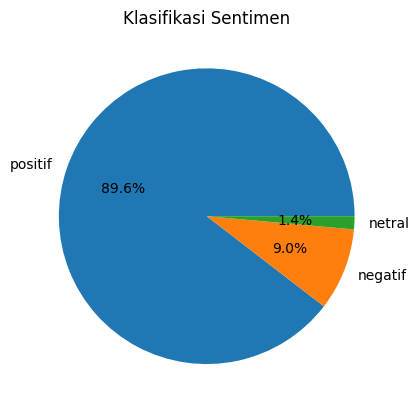

In [ ]:
label_count = df['sentiment'].value_counts()
label_percent = df['sentiment'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Jumlah': label_count,
    'Persentase (%)': label_percent.round(2)
}).reindex(['negatif','netral','positif'])

print("\nKlasifikasi Sentimen:")
print(label_summary)

label_summary.to_csv(f"{SAVE_DIR}/02_distribusi_sentimen.csv")

# Visualisasi
label_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Klasifikasi Sentimen')
plt.ylabel('')
plt.savefig(f"{SAVE_DIR}/pie_sentimen.png")
plt.show()

df.to_csv(f"{SAVE_DIR}/02_dataset_labeled.csv", index=False)

# **PREPROCESSING**

In [ ]:
# Inisialisasi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords('id'))

# ======================
# 1. CASE FOLDING
# ======================
def case_folding(text):
    return str(text).lower()

# ======================
# 2. CLEANING
# ======================
def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)        # hapus mention & hashtag
    text = re.sub(r'\d+', '', text)              # hapus angka
    text = re.sub(r'[^\w\s]', '', text)          # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()     # hapus spasi berlebih
    return text

# ======================
# 3. STOPWORD REMOVAL
# ======================
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# ======================
# 4. STEMMING
# ======================
def stemming(text):
    words = text.split()
    words = [stemmer.stem(w) for w in words]
    return " ".join(words)

# ======================
# TERAPKAN KE DATASET
# ======================
df['case_folding'] = df['content'].apply(case_folding)
df['cleaning'] = df['case_folding'].apply(cleaning)
df['stopword'] = df['cleaning'].apply(remove_stopwords)
df['stemming'] = df['stopword'].apply(stemming)

# hasil akhir
df['processed'] = df['stemming']

# ======================
# HAPUS DATA KOSONG & DUPLIKAT
# ======================
df = df[df['processed'].str.strip() != '']
df = df.drop_duplicates(subset=['processed'])

# ======================
# CEK HASIL
# ======================
print("Jumlah data setelah preprocessing:", len(df))
df[['content','case_folding','cleaning','stopword','stemming']].head(10)

Jumlah data setelah preprocessing: 6574


,content,case_folding,cleaning,stopword,stemming
1842,wow aplikasi yang sangat hebat membantu kita u...,wow aplikasi yang sangat hebat membantu kita u...,wow aplikasi yang sangat hebat membantu kita u...,wow aplikasi hebat membantu hidup sehat,wow aplikasi hebat bantu hidup sehat
1843,tlong lah kita order obt maunya cepat kasih pi...,tlong lah kita order obt maunya cepat kasih pi...,tlong lah kita order obt maunya cepat kasih pi...,tlong order obt maunya cepat kasih pilihan dri...,tlong order obt mau cepat kasih pilih driver y...
1844,suka sih konsul di halodoc. dokternya juga ram...,suka sih konsul di halodoc. dokternya juga ram...,suka sih konsul di halodoc dokternya juga rama...,suka sih konsul halodoc dokternya ramah ramah ...,suka sih konsul halodoc dokter ramah ramah sehat
1845,Dokter nya sangat komunikatif,dokter nya sangat komunikatif,dokter nya sangat komunikatif,dokter nya komunikatif,dokter nya komunikatif
1846,dokternya ramah banget...semoga cocok ya,dokternya ramah banget...semoga cocok ya,dokternya ramah bangetsemoga cocok ya,dokternya ramah bangetsemoga cocok ya,dokter ramah bangetsemoga cocok ya
1847,sangat membantu,sangat membantu,sangat membantu,membantu,bantu
1848,Aplikasi yang sangat membantu seputar konsulta...,aplikasi yang sangat membantu seputar konsulta...,aplikasi yang sangat membantu seputar konsulta...,aplikasi membantu seputar konsultasi kesehatan...,aplikasi bantu putar konsultasi sehat dokter d...
1849,respon cepat dan tepat,respon cepat dan tepat,respon cepat dan tepat,respon cepat,respon cepat
1850,"Easy to Use, Useful dan Thank You...","easy to use, useful dan thank you...",easy to use useful dan thank you,easy to use useful thank you,easy to use useful thank you
1851,"pelayanan buruk, next time buatkan fitur pemba...","pelayanan buruk, next time buatkan fitur pemba...",pelayanan buruk next time buatkan fitur pembat...,pelayanan buruk next time buatkan fitur pembat...,layan buruk next time buat fitur batal kasih r...


# **Persiapan data**

In [ ]:
X = df['processed']
y = df['sentiment']

# **TF IDF + SVM**


=== TF-IDF ===
Accuracy : 0.9085792515972011
Precision: 0.9125701050210644
Recall   : 0.9085792515972011
F1 Score : 0.9095748594675258


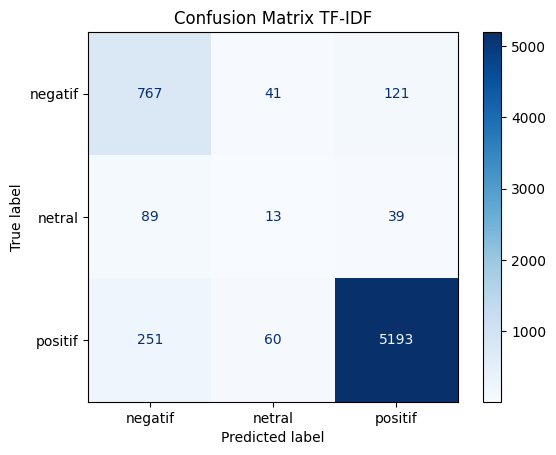

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

svm = SVC(kernel='linear', class_weight='balanced')
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_tfidf = cross_val_predict(svm, X_tfidf, y, cv=kfold)

# Evaluasi TF-IDF
acc_tfidf = accuracy_score(y, y_pred_tfidf)
prec_tfidf = precision_score(y, y_pred_tfidf, average='weighted')
rec_tfidf = recall_score(y, y_pred_tfidf, average='weighted')
f1_tfidf = f1_score(y, y_pred_tfidf, average='weighted')

print("\n=== TF-IDF ===")
print("Accuracy :", acc_tfidf)
print("Precision:", prec_tfidf)
print("Recall   :", rec_tfidf)
print("F1 Score :", f1_tfidf)

# Confusion Matrix TF-IDF
labels = ['negatif','netral','positif']
cm_tfidf = confusion_matrix(y, y_pred_tfidf, labels=labels)

ConfusionMatrixDisplay(cm_tfidf, display_labels=labels).plot(cmap='Blues')
plt.title('Confusion Matrix TF-IDF')
plt.savefig(f"{SAVE_DIR}/cm_tfidf.png")
plt.show()

# **Word2vec +SVM**


=== Word2Vec ===
Accuracy : 0.7916032856708245
Precision: 0.9144097200959881
Recall   : 0.7916032856708245
F1 Score : 0.8453354973802736


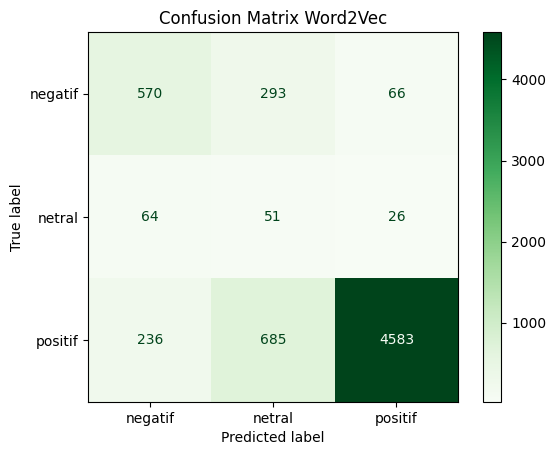

In [ ]:
tokenized = [text.split() for text in X]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=200,
    window=5,
    min_count=1,
    sg=1,
    seed=42,
    workers=4
)

def doc_vector(doc):
    words = doc.split()
    vec = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vec, axis=0) if vec else np.zeros(200)

X_w2v = np.array([doc_vector(text) for text in X])

y_pred_w2v = cross_val_predict(svm, X_w2v, y, cv=kfold)

# Evaluasi Word2Vec
acc_w2v = accuracy_score(y, y_pred_w2v)
prec_w2v = precision_score(y, y_pred_w2v, average='weighted')
rec_w2v = recall_score(y, y_pred_w2v, average='weighted')
f1_w2v = f1_score(y, y_pred_w2v, average='weighted')

print("\n=== Word2Vec ===")
print("Accuracy :", acc_w2v)
print("Precision:", prec_w2v)
print("Recall   :", rec_w2v)
print("F1 Score :", f1_w2v)

# Confusion Matrix Word2Vec
cm_w2v = confusion_matrix(y, y_pred_w2v, labels=labels)

ConfusionMatrixDisplay(cm_w2v, display_labels=labels).plot(cmap='Greens')
plt.title('Confusion Matrix Word2Vec')
plt.savefig(f"{SAVE_DIR}/cm_w2v.png")
plt.show()


# **Perbandingan Model**


Perbandingan Model:
     Metode  Accuracy  Precision    Recall  F1-Score
0    TF-IDF  0.908579    0.91257  0.908579  0.909575
1  Word2Vec  0.791603    0.91441  0.791603  0.845335


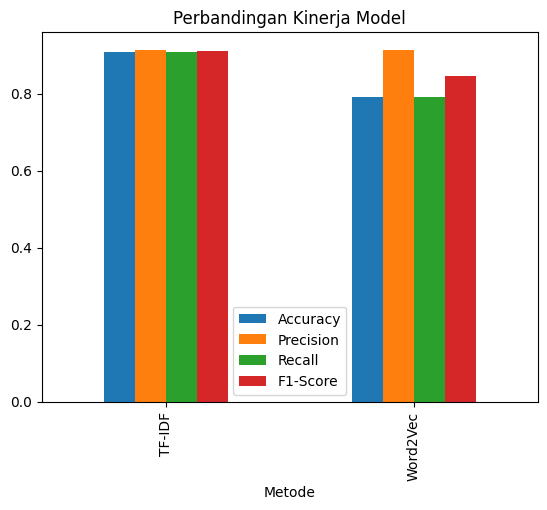

In [ ]:
results = pd.DataFrame({
    'Metode': ['TF-IDF','Word2Vec'],
    'Accuracy': [acc_tfidf, acc_w2v],
    'Precision': [prec_tfidf, prec_w2v],
    'Recall': [rec_tfidf, rec_w2v],
    'F1-Score': [f1_tfidf, f1_w2v]
})

print("\nPerbandingan Model:")
print(results)

results.to_csv(f"{SAVE_DIR}/hasil_perbandingan.csv", index=False)

results.set_index('Metode').plot(kind='bar')
plt.title('Perbandingan Kinerja Model')
plt.savefig(f"{SAVE_DIR}/perbandingan_model.png")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')